Q3: Feature Engineering and Regression Pipeline

In [ ]:
import pandas as pd

df = pd.read_csv("C:\\Users\\sriva\\Downloads\\data\\q3_retail_promotions.csv")
# Date Feature Engineering
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print(df.head())

df = df.sort_values(by='transaction_date')

# Temporal Train-Test split
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train size:", len(train_df))
print("Test size:", len(test_df))

  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   day_of_week  is_month_end  
0            5             0  
1            5             0  
2          

A random train-test split is inappropriate for time-ordered data because it breaks the natural temporal sequence of events. 

In real-world scenarios, models are used to predict future outcomes based on past data. A random split may place future observations in the training set and past observations in the test set, leading to data leakage.

This results in overly optimistic performance metrics because the model indirectly learns patterns from the future.

By using a temporal split (training on older data and testing on newer data), we better simulate real-world conditions and obtain a more reliable estimate of model performance.

3: Preprocessing Pipeline

In [8]:

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Feature groups
categorical_features = ['promotion_type', 'location_type', 'store_size']

numerical_features = [
    'store_id', 'competition_density',
    'is_weekend', 'is_festival',
    'year', 'month', 'day_of_week', 'is_month_end'
]

# Preprocessing for each type
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
numerical_transformer = StandardScaler()

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numerical_transformer, numerical_features)
    ]
)

# Final pipeline (only preprocessing for now)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Separate features and target
X_train = train_df.drop(columns=['items_sold'])
y_train = train_df['items_sold']

X_test = test_df.drop(columns=['items_sold'])
y_test = test_df['items_sold']

# Fit on training data only
pipeline.fit(X_train)

# Transform both sets
X_train_transformed = pipeline.transform(X_train)
X_test_transformed = pipeline.transform(X_test)


4: Model Training and Evaluation


Linear Regression Performance:
RMSE: 27.12
MAE: 21.05

Random Forest Performance:
RMSE: 30.81
MAE: 24.22


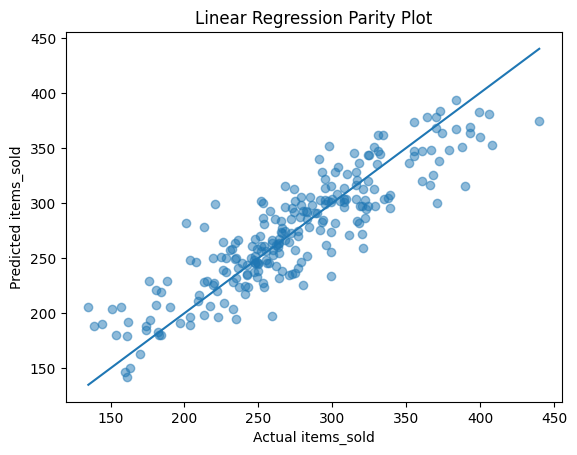

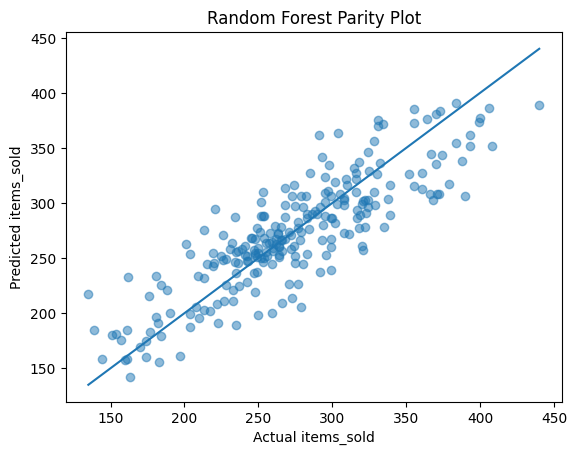


Top 5 Important Features:
                feature  importance
14          is_festival    0.173420
10     store_size_small    0.166921
7   location_type_urban    0.108035
17          day_of_week    0.083147
13           is_weekend    0.064329


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error


# 1. Define Models in Pipelines

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

# 2. Train Models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# 3. Predictions
lr_preds = lr_pipeline.predict(X_test)
rf_preds = rf_pipeline.predict(X_test)

# 4. Evaluation Metrics
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n{model_name} Performance:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")

evaluate_model(y_test, lr_preds, "Linear Regression")
evaluate_model(y_test, rf_preds, "Random Forest")

# 5. Parity Plot Function
def parity_plot(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred, alpha=0.5)
    
    # Diagonal reference line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])
    
    plt.xlabel("Actual items_sold")
    plt.ylabel("Predicted items_sold")
    plt.title(title)
    plt.show()

# Plot for both models
parity_plot(y_test, lr_preds, "Linear Regression Parity Plot")
parity_plot(y_test, rf_preds, "Random Forest Parity Plot")

# 6. Feature Importances (RF)

# Get feature names after preprocessing
ohe_features = rf_pipeline.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(['promotion_type', 'location_type', 'store_size'])

num_features = rf_pipeline.named_steps['preprocessor'] \
    .transformers_[1][2]

all_features = np.concatenate([ohe_features, num_features])

# Get importances
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nTop 5 Important Features:")
print(feature_importance_df.head(5))